In [1]:
import pandas as pd
import numpy as np
import os

In [3]:
os.listdir()

['.ipynb_checkpoints',
 'DIM_CALENDAR (2).xlsx',
 'DIM_CATEGORY (2).csv',
 'DIM_PRODUCT (1).xlsx',
 'DIM_SEGMENT (1).xlsx',
 'Entregable3.ipynb',
 'FACT_SALES (1).csv',
 'productos_clusterizados.csv',
 'Proyecto 3.ipynb',
 'Tarea M27-CD-Juan Carlos Kern - 2.docx',
 'Tarea M27-CD-Juan Carlos Kern.docx',
 'Tarea M27-CD-Juan Carlos Kern.pdf']

In [5]:
# 3. Cargar los cinco archivos que conforman la base de datos
dim_calendar = pd.read_excel('DIM_CALENDAR (2).xlsx')
dim_category = pd.read_csv('DIM_CATEGORY (2).csv')
dim_product = pd.read_excel('DIM_PRODUCT (1).xlsx')
dim_segment = pd.read_excel('DIM_SEGMENT (1).xlsx')
fact_sales = pd.read_csv('FACT_SALES (1).csv')

In [7]:
# 4. Revisar el número de filas, columnas y los nombres de las variables de cada archivo

datasets = {
    'DIM_CALENDAR': dim_calendar,
    'DIM_CATEGORY': dim_category,
    'DIM_PRODUCT': dim_product,
    'DIM_SEGMENT': dim_segment,
    'FACT_SALES': fact_sales
}

for nombre, df in datasets.items():
    print(f'\n{nombre}')
    print(f'Dimensiones: {df.shape}')
    print('Columnas:')
    print(df.columns.tolist())


DIM_CALENDAR
Dimensiones: (156, 5)
Columnas:
['WEEK', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE']

DIM_CATEGORY
Dimensiones: (5, 2)
Columnas:
['ID_CATEGORY', 'CATEGORY']

DIM_PRODUCT
Dimensiones: (505, 9)
Columnas:
['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY', 'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3']

DIM_SEGMENT
Dimensiones: (53, 6)
Columnas:
['CATEGORY', 'ATTR1', 'ATTR2', 'ATTR3', 'FORMAT', 'SEGMENT']

FACT_SALES
Dimensiones: (122002, 6)
Columnas:
['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION']


In [9]:
# 5. Ajustar y estandarizar los nombres de las columnas

dim_calendar = dim_calendar.rename(columns={
    'WEEK': 'WeekCode',
    'YEAR': 'Year',
    'MONTH': 'Month',
    'WEEK_NUMBER': 'WeekNumber',
    'DATE': 'Date'
})

dim_category = dim_category.rename(columns={
    'ID_CATEGORY': 'CategoryID',
    'CATEGORY': 'CategoryName'
})

dim_product = dim_product.rename(columns={
    'MANUFACTURER': 'Manufacturer',
    'BRAND': 'Brand',
    'ITEM': 'ItemCode',
    'ITEM_DESCRIPTION': 'ItemDescription',
    'CATEGORY': 'CategoryID',
    'FORMAT': 'Format',
    'ATTR1': 'Attr1',
    'ATTR2': 'Attr2',
    'ATTR3': 'Attr3'
})

dim_segment = dim_segment.rename(columns={
    'CATEGORY': 'CategoryID',
    'ATTR1': 'Attr1',
    'ATTR2': 'Attr2',
    'ATTR3': 'Attr3',
    'FORMAT': 'Format',
    'SEGMENT': 'Segment'
})

fact_sales = fact_sales.rename(columns={
    'WEEK': 'WeekCode',
    'ITEM_CODE': 'ItemCode',
    'TOTAL_UNIT_SALES': 'TotalUnitSales',
    'TOTAL_VALUE_SALES': 'TotalValueSales',
    'TOTAL_UNIT_AVG_WEEKLY_SALES': 'TotalUnitAvgWeeklySales',
    'REGION': 'Region'
})

In [11]:
# 6. Verificar los nuevos nombres de las columnas

datasets = {
    'DIM_CALENDAR': dim_calendar,
    'DIM_CATEGORY': dim_category,
    'DIM_PRODUCT': dim_product,
    'DIM_SEGMENT': dim_segment,
    'FACT_SALES': fact_sales
}

for nombre, df in datasets.items():
    print(f'\n{nombre}')
    print(df.columns.tolist())


DIM_CALENDAR
['WeekCode', 'Year', 'Month', 'WeekNumber', 'Date']

DIM_CATEGORY
['CategoryID', 'CategoryName']

DIM_PRODUCT
['Manufacturer', 'Brand', 'ItemCode', 'ItemDescription', 'CategoryID', 'Format', 'Attr1', 'Attr2', 'Attr3']

DIM_SEGMENT
['CategoryID', 'Attr1', 'Attr2', 'Attr3', 'Format', 'Segment']

FACT_SALES
['WeekCode', 'ItemCode', 'TotalUnitSales', 'TotalValueSales', 'TotalUnitAvgWeeklySales', 'Region']


In [13]:
# 7. Revisar los tipos de datos y la cantidad de valores nulos

for nombre, df in datasets.items():
    print(f'\n{"="*50}')
    print(nombre)
    print(f'{"="*50}')

    print('\nTipos de datos:')
    print(df.dtypes)

    print('\nValores nulos:')
    print(df.isnull().sum())


DIM_CALENDAR

Tipos de datos:
WeekCode              object
Year                   int64
Month                  int64
WeekNumber             int64
Date          datetime64[ns]
dtype: object

Valores nulos:
WeekCode      0
Year          0
Month         0
WeekNumber    0
Date          0
dtype: int64

DIM_CATEGORY

Tipos de datos:
CategoryID       int64
CategoryName    object
dtype: object

Valores nulos:
CategoryID      0
CategoryName    0
dtype: int64

DIM_PRODUCT

Tipos de datos:
Manufacturer       object
Brand              object
ItemCode           object
ItemDescription    object
CategoryID          int64
Format             object
Attr1              object
Attr2              object
Attr3              object
dtype: object

Valores nulos:
Manufacturer       0
Brand              0
ItemCode           2
ItemDescription    0
CategoryID         0
Format             0
Attr1              6
Attr2              0
Attr3              6
dtype: int64

DIM_SEGMENT

Tipos de datos:
CategoryID     int6

In [15]:
# 8. Revisar si las llaves de las tablas dimensionales contienen duplicados

print('DIM_CALENDAR')
print('Filas:', len(dim_calendar))
print('WeekCode únicos:', dim_calendar['WeekCode'].nunique())
print('WeekCode duplicados:', dim_calendar['WeekCode'].duplicated().sum())

print('\nDIM_PRODUCT')
print('Filas:', len(dim_product))
print('ItemCode únicos:', dim_product['ItemCode'].nunique())
print('ItemCode duplicados:', dim_product['ItemCode'].duplicated().sum())

print('\nDIM_CATEGORY')
print('Filas:', len(dim_category))
print('CategoryID únicos:', dim_category['CategoryID'].nunique())
print('CategoryID duplicados:', dim_category['CategoryID'].duplicated().sum())

print('\nDIM_SEGMENT')

segment_keys = ['CategoryID', 'Attr1', 'Attr2', 'Attr3', 'Format']

print('Filas:', len(dim_segment))
print(
    'Combinaciones únicas:',
    dim_segment[segment_keys].drop_duplicates().shape[0]
)
print(
    'Combinaciones duplicadas:',
    dim_segment.duplicated(subset=segment_keys).sum()
)

DIM_CALENDAR
Filas: 156
WeekCode únicos: 156
WeekCode duplicados: 0

DIM_PRODUCT
Filas: 505
ItemCode únicos: 503
ItemCode duplicados: 1

DIM_CATEGORY
Filas: 5
CategoryID únicos: 5
CategoryID duplicados: 0

DIM_SEGMENT
Filas: 53
Combinaciones únicas: 53
Combinaciones duplicadas: 0


In [17]:
# 9. Verificar que las llaves de FACT_SALES tengan correspondencia en las dimensiones

items_sin_producto = fact_sales.loc[
    ~fact_sales['ItemCode'].isin(dim_product['ItemCode']),
    'ItemCode'
].nunique()

semanas_sin_calendario = fact_sales.loc[
    ~fact_sales['WeekCode'].isin(dim_calendar['WeekCode']),
    'WeekCode'
].nunique()

print('ItemCode de FACT_SALES sin correspondencia en DIM_PRODUCT:',
      items_sin_producto)

print('WeekCode de FACT_SALES sin correspondencia en DIM_CALENDAR:',
      semanas_sin_calendario)

ItemCode de FACT_SALES sin correspondencia en DIM_PRODUCT: 0
WeekCode de FACT_SALES sin correspondencia en DIM_CALENDAR: 0


In [19]:
# 10. Revisar los registros con valores nulos en DIM_PRODUCT

productos_con_nulos = dim_product[
    dim_product[['ItemCode', 'Attr1', 'Attr3']].isnull().any(axis=1)
]

productos_con_nulos

,Manufacturer,Brand,ItemCode,ItemDescription,CategoryID,Format,Attr1,Attr2,Attr3
33,WHITE MAGIC,WHITE MAGIC,0079893431208,9WHITE MAGIC BOT.PLAS 3970ML IMP 0079893431208,1,LIQUIDO,NaN,CLORO,NaN
107,INDS. ALEN,CLORALEX,7501025401023,CLORALEX EXTRA SENSACION FRUTALES BOT PLAST 95...,1,LIQUIDO,NaN,CLORO,NaN
143,INDS. ALEN,BLANCATEL,7501025402259,BLANCATEL BLANQUEADOR BOTELLA 1.8LT 7501025402259,1,LIQUIDO,NaN,CLORO,NaN
343,CLOROX,CLOROX,7501071901591,CLOROX BLANQUEADOR PARAISO TROPICAL 3800 ML NA...,1,LIQUIDO,NaN,CLORO,NaN
469,OTHERS FABRICANTE UNIF.,OTHERS MARCA UNIF.,7502217411776,KLEEN CLORO BOTELLA 1000 ML NAL 7502217411776,1,LIQUIDO,NaN,CLORO,NaN
495,IBERIA,IBERIA,8411660040503,9IBERIA BLANQUEADOR POLVO 250 GR IMP 841166004...,1,POLVO,NaN,CLORO,NaN
502,INDS. ALEN,CLORALEX,NaN,CLORALEX EL RENDIDOR BOT PLAST 2LT,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
503,CLOROX,CLOROX,NaN,CLOROX MASCOTAS BLANQUEADOR+DETERGENTE GALON 10L,1,LIQUIDO,CLORO,CLORO,MASCOTAS


In [21]:
# 11. Verificar si existen ItemCode duplicados reales, excluyendo valores nulos

itemcode_duplicados_reales = dim_product[
    dim_product['ItemCode'].notna() &
    dim_product['ItemCode'].duplicated(keep=False)
]

print('ItemCode duplicados reales:', len(itemcode_duplicados_reales))

itemcode_duplicados_reales

ItemCode duplicados reales: 0


,Manufacturer,Brand,ItemCode,ItemDescription,CategoryID,Format,Attr1,Attr2,Attr3


In [23]:
# 12. Verificar la correspondencia de los productos con categorías y segmentos

categorias_sin_correspondencia = dim_product.loc[
    ~dim_product['CategoryID'].isin(dim_category['CategoryID']),
    'CategoryID'
].nunique()

segment_check = dim_product.merge(
    dim_segment,
    on=['CategoryID', 'Attr1', 'Attr2', 'Attr3', 'Format'],
    how='left',
    indicator=True
)

productos_sin_segmento = segment_check[
    segment_check['_merge'] == 'left_only'
]

print(
    'CategoryID de DIM_PRODUCT sin correspondencia en DIM_CATEGORY:',
    categorias_sin_correspondencia
)

print(
    'Productos sin correspondencia en DIM_SEGMENT:',
    len(productos_sin_segmento)
)

CategoryID de DIM_PRODUCT sin correspondencia en DIM_CATEGORY: 0
Productos sin correspondencia en DIM_SEGMENT: 6


In [25]:
# 13. Preparar DIM_PRODUCT eliminando únicamente registros sin ItemCode

dim_product_merge = dim_product.dropna(
    subset=['ItemCode']
).copy()

print('Filas originales de DIM_PRODUCT:', len(dim_product))
print('Filas disponibles para el merge:', len(dim_product_merge))
print(
    'ItemCode duplicados:',
    dim_product_merge['ItemCode'].duplicated().sum()
)

Filas originales de DIM_PRODUCT: 505
Filas disponibles para el merge: 503
ItemCode duplicados: 0


In [27]:
# 14. Consolidar FACT_SALES con las tablas dimensionales

df_consolidado = (
    fact_sales
    .merge(
        dim_product_merge,
        on='ItemCode',
        how='left',
        validate='many_to_one'
    )
    .merge(
        dim_calendar,
        on='WeekCode',
        how='left',
        validate='many_to_one'
    )
    .merge(
        dim_category,
        on='CategoryID',
        how='left',
        validate='many_to_one'
    )
    .merge(
        dim_segment,
        on=['CategoryID', 'Attr1', 'Attr2', 'Attr3', 'Format'],
        how='left',
        validate='many_to_one'
    )
)

In [29]:
# 15. Verificar que no se hayan perdido ni multiplicado registros

print('Filas originales de FACT_SALES:', len(fact_sales))
print('Filas del dataset consolidado:', len(df_consolidado))
print('Columnas del dataset consolidado:', df_consolidado.shape[1])

print('\nDimensiones del dataset consolidado:')
print(df_consolidado.shape)

Filas originales de FACT_SALES: 122002
Filas del dataset consolidado: 122002
Columnas del dataset consolidado: 20

Dimensiones del dataset consolidado:
(122002, 20)


In [31]:
# 16. Visualizar las primeras filas del dataset consolidado

df_consolidado.head()

,WeekCode,ItemCode,TotalUnitSales,TotalValueSales,TotalUnitAvgWeeklySales,Region,Manufacturer,Brand,ItemDescription,CategoryID,Format,Attr1,Attr2,Attr3,Year,Month,WeekNumber,Date,CategoryName,Segment
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28,FABRIC TREATMENT and SANIT\r\n,POWDER


In [33]:
# 17. Revisar la cantidad de valores nulos en el dataset consolidado

df_consolidado.isnull().sum()

WeekCode                   0
ItemCode                   0
TotalUnitSales             0
TotalValueSales            0
TotalUnitAvgWeeklySales    0
Region                     0
Manufacturer               0
Brand                      0
ItemDescription            0
CategoryID                 0
Format                     0
Attr1                      0
Attr2                      0
Attr3                      0
Year                       0
Month                      0
WeekNumber                 0
Date                       0
CategoryName               0
Segment                    0
dtype: int64

In [35]:
# 18. Seleccionar y preparar las características para el clustering de productos

# Variables descriptivas que identifican y caracterizan a cada producto
columnas_producto = [
    'ItemCode',
    'ItemDescription',
    'Manufacturer',
    'Brand',
    'CategoryName',
    'Format',
    'Attr1',
    'Attr2',
    'Attr3',
    'Segment'
]

# 1. Agregar las ventas para obtener una fila por producto
df_productos_cluster = (
    df_consolidado
    .groupby(columnas_producto, dropna=False)
    .agg(
        TotalUnitSales=('TotalUnitSales', 'sum'),
        TotalValueSales=('TotalValueSales', 'sum'),
        AvgWeeklySales=('TotalUnitAvgWeeklySales', 'mean')
    )
    .reset_index()
)

# 2. Incorporar la información geográfica:
# ventas en valor de cada producto por región
ventas_por_region = (
    df_consolidado
    .pivot_table(
        index='ItemCode',
        columns='Region',
        values='TotalValueSales',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

# Renombrar las columnas regionales para identificarlas fácilmente
ventas_por_region.columns = [
    'ItemCode' if col == 'ItemCode'
    else f'Region_{col}'
    for col in ventas_por_region.columns
]

# 3. Unir las características del producto con su comportamiento regional
df_productos_cluster = df_productos_cluster.merge(
    ventas_por_region,
    on='ItemCode',
    how='left',
    validate='one_to_one'
)

# 4. Verificación del resultado
print('Dimensiones del dataset original:', df_consolidado.shape)
print('Productos únicos en el consolidado:', df_consolidado['ItemCode'].nunique())
print('Dimensiones del dataset para clustering:', df_productos_cluster.shape)

print('\nColumnas seleccionadas:')
print(df_productos_cluster.columns.tolist())

df_productos_cluster.head()

Dimensiones del dataset original: (122002, 20)
Productos únicos en el consolidado: 350
Dimensiones del dataset para clustering: (350, 20)

Columnas seleccionadas:
['ItemCode', 'ItemDescription', 'Manufacturer', 'Brand', 'CategoryName', 'Format', 'Attr1', 'Attr2', 'Attr3', 'Segment', 'TotalUnitSales', 'TotalValueSales', 'AvgWeeklySales', 'Region_TOTAL AUTOS AREA 1', 'Region_TOTAL AUTOS AREA 2', 'Region_TOTAL AUTOS AREA 3', 'Region_TOTAL AUTOS AREA 4', 'Region_TOTAL AUTOS AREA 5', 'Region_TOTAL AUTOS AREA 6', 'Region_TOTAL AUTOS SCANNING MEXICO']


,ItemCode,ItemDescription,Manufacturer,Brand,CategoryName,Format,Attr1,Attr2,Attr3,Segment,TotalUnitSales,TotalValueSales,AvgWeeklySales,Region_TOTAL AUTOS AREA 1,Region_TOTAL AUTOS AREA 2,Region_TOTAL AUTOS AREA 3,Region_TOTAL AUTOS AREA 4,Region_TOTAL AUTOS AREA 5,Region_TOTAL AUTOS AREA 6,Region_TOTAL AUTOS SCANNING MEXICO
0,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,INDS. ALEN,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,6.042,24.663,4.860489,6.842,0.260,0.036,1.026,0.208,3.964,12.327
1,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,INDS. ALEN,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,1423.786,12423.156,35.166597,2007.354,2509.695,242.517,110.527,334.793,1006.697,6211.573
2,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,INDS. ALEN,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,46461.839,658584.568,92.527904,65106.692,99576.476,29494.535,28105.844,30704.544,76304.191,329292.286
3,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,INDS. ALEN,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,48445.151,1139233.787,112.098525,89383.378,150348.453,89594.746,80535.131,86600.770,73154.416,569616.893
4,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,INDS. ALEN,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,CLORO,CLORO,NO DEFINIDO,BLEACH,28334.417,1146849.632,60.226977,62232.003,92553.455,93338.920,79101.489,102355.832,143843.121,573424.812


In [37]:
# 19. Preparar y estandarizar las características para K-Means

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Creamos una copia para no modificar el DataFrame preparado anteriormente
df_modelo = df_productos_cluster.copy()


# ------------------------------------------------------------
# 1. Limpiar textos de las variables categóricas
# ------------------------------------------------------------

columnas_categoricas = [
    'CategoryName',
    'Format',
    'Attr1',
    'Attr2',
    'Attr3',
    'Segment'
]

for col in columnas_categoricas:
    df_modelo[col] = (
        df_modelo[col]
        .astype(str)
        .str.replace(r'[\r\n]+', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )


# ------------------------------------------------------------
# 2. Identificar las columnas correspondientes a regiones
# ------------------------------------------------------------

columnas_region = [
    col for col in df_modelo.columns
    if col.startswith('Region_')
]

print('Columnas regionales encontradas:')
print(columnas_region)


# ------------------------------------------------------------
# 3. Convertir ventas regionales absolutas en proporciones
# ------------------------------------------------------------

for col in columnas_region:
    nueva_columna = col.replace('Region_', 'Share_')
    
    df_modelo[nueva_columna] = (
        df_modelo[col] /
        df_modelo['TotalValueSales'].replace(0, np.nan)
    ).fillna(0)


columnas_share_region = [
    col for col in df_modelo.columns
    if col.startswith('Share_')
]


# ------------------------------------------------------------
# 4. Seleccionar variables numéricas para el clustering
# ------------------------------------------------------------

columnas_numericas = [
    'TotalUnitSales',
    'TotalValueSales',
    'AvgWeeklySales'
] + columnas_share_region


# ------------------------------------------------------------
# 5. Crear el preprocesador
# ------------------------------------------------------------

preprocesador = ColumnTransformer(
    transformers=[
        (
            'numericas',
            StandardScaler(),
            columnas_numericas
        ),
        (
            'categoricas',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            columnas_categoricas
        )
    ],
    remainder='drop'
)


# ------------------------------------------------------------
# 6. Aplicar la transformación
# ------------------------------------------------------------

X_cluster = preprocesador.fit_transform(df_modelo)


# ------------------------------------------------------------
# 7. Obtener los nombres de las variables transformadas
# ------------------------------------------------------------

nombres_variables = preprocesador.get_feature_names_out()

df_cluster_preparado = pd.DataFrame(
    X_cluster,
    columns=nombres_variables,
    index=df_modelo.index
)


# ------------------------------------------------------------
# 8. Verificar el resultado
# ------------------------------------------------------------

print('\nDimensiones antes del preprocesamiento:',
      df_modelo.shape)

print('Dimensiones después del preprocesamiento:',
      df_cluster_preparado.shape)

print('\nValores nulos después del preprocesamiento:',
      df_cluster_preparado.isnull().sum().sum())

print('\nPrimeras variables generadas:')
print(df_cluster_preparado.columns.tolist()[:20])

df_cluster_preparado.head()

Columnas regionales encontradas:
['Region_TOTAL AUTOS AREA 1', 'Region_TOTAL AUTOS AREA 2', 'Region_TOTAL AUTOS AREA 3', 'Region_TOTAL AUTOS AREA 4', 'Region_TOTAL AUTOS AREA 5', 'Region_TOTAL AUTOS AREA 6', 'Region_TOTAL AUTOS SCANNING MEXICO']

Dimensiones antes del preprocesamiento: (350, 27)
Dimensiones después del preprocesamiento: (350, 32)

Valores nulos después del preprocesamiento: 0

Primeras variables generadas:
['numericas__TotalUnitSales', 'numericas__TotalValueSales', 'numericas__AvgWeeklySales', 'numericas__Share_TOTAL AUTOS AREA 1', 'numericas__Share_TOTAL AUTOS AREA 2', 'numericas__Share_TOTAL AUTOS AREA 3', 'numericas__Share_TOTAL AUTOS AREA 4', 'numericas__Share_TOTAL AUTOS AREA 5', 'numericas__Share_TOTAL AUTOS AREA 6', 'numericas__Share_TOTAL AUTOS SCANNING MEXICO', 'categoricas__Format_GEL', 'categoricas__Format_LIQUIDO', 'categoricas__Format_POLVO', 'categoricas__Format_TOALLAS', 'categoricas__Attr1_PRELAVADOR', 'categoricas__Attr1_SAFE BLEACH', 'categoricas__Att

,numericas__TotalUnitSales,numericas__TotalValueSales,numericas__AvgWeeklySales,numericas__Share_TOTAL AUTOS AREA 1,numericas__Share_TOTAL AUTOS AREA 2,numericas__Share_TOTAL AUTOS AREA 3,numericas__Share_TOTAL AUTOS AREA 4,numericas__Share_TOTAL AUTOS AREA 5,numericas__Share_TOTAL AUTOS AREA 6,numericas__Share_TOTAL AUTOS SCANNING MEXICO,...,categoricas__Attr3_PRE LAVADOR,categoricas__Attr3_ROPA BEBE,categoricas__Attr3_ROSA,categoricas__Attr3_SANITIZANTE,categoricas__Segment_BLEACH,categoricas__Segment_LIQUID & GEL,categoricas__Segment_OTHERS,categoricas__Segment_POWDER,categoricas__Segment_PRETREAT,categoricas__Segment_SANITIZER
0,-0.260142,-0.303656,-0.197162,1.430809,-0.846754,-0.847070,-0.186301,-0.956667,0.765062,-2.961441,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.071147,-0.184236,1.516228,0.569904,0.509570,-0.588633,-0.634544,-0.740196,0.019797,0.161325,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,10.595340,6.039475,4.759214,0.103747,0.149586,-0.227151,-0.171563,-0.510192,0.345490,0.168281,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,11.058787,10.669003,5.865661,-0.047860,0.013409,0.257336,0.212430,-0.166528,-0.137501,0.168221,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,6.359444,10.742357,2.933044,-0.227682,-0.349771,0.296578,0.188863,-0.011817,0.434927,0.168169,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


C:\Users\juanc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\juanc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\juanc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\juanc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Evaluación de diferentes números de clusters:


C:\Users\juanc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,k,Inercia,Silhouette
0,2,3786.870221,0.706892
1,3,3306.199173,0.190513
2,4,2891.291442,0.262455
3,5,2550.261790,0.287265
4,6,2250.054972,0.297184
5,7,2008.649796,0.273683
6,8,1747.156731,0.293610
7,9,1539.506945,0.300057
8,10,1442.067737,0.277894


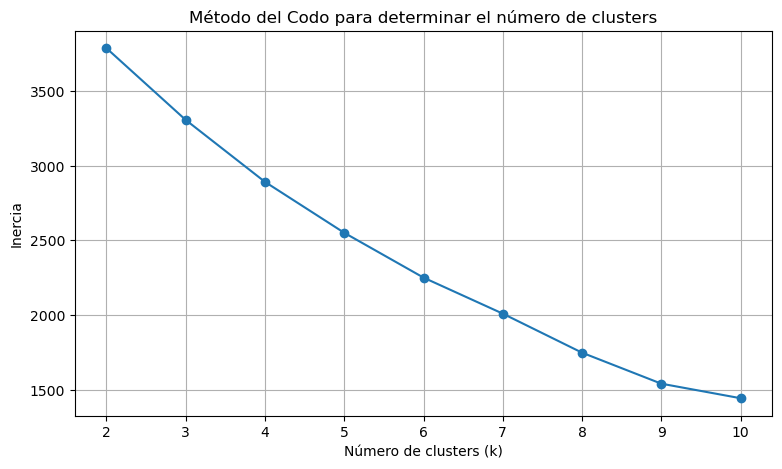

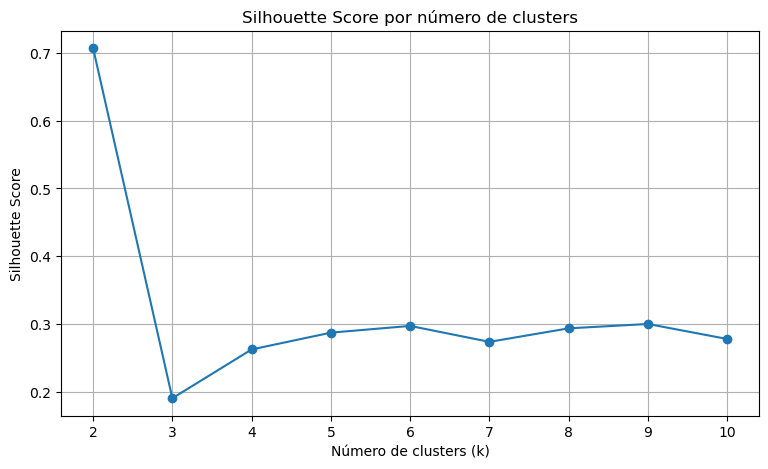

In [39]:
# 20. Determinar el número adecuado de clusters
#     mediante el Método del Codo y Silhouette Score

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ------------------------------------------------------------
# 1. Definir el rango de clusters a evaluar
# ------------------------------------------------------------

rango_k = range(2, 11)

inercias = []
silhouettes = []


# ------------------------------------------------------------
# 2. Probar K-Means para diferentes valores de k
# ------------------------------------------------------------

for k in rango_k:
    
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    etiquetas = modelo_kmeans.fit_predict(df_cluster_preparado)
    
    # Inercia: suma de distancias cuadráticas
    # de cada observación a su centroide
    inercias.append(modelo_kmeans.inertia_)
    
    # Silhouette Score:
    # mide cohesión interna y separación entre clusters
    silhouettes.append(
        silhouette_score(
            df_cluster_preparado,
            etiquetas
        )
    )


# ------------------------------------------------------------
# 3. Crear tabla resumen
# ------------------------------------------------------------

evaluacion_clusters = pd.DataFrame({
    'k': list(rango_k),
    'Inercia': inercias,
    'Silhouette': silhouettes
})

print('Evaluación de diferentes números de clusters:')
display(evaluacion_clusters)


# ------------------------------------------------------------
# 4. Método del Codo
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    evaluacion_clusters['k'],
    evaluacion_clusters['Inercia'],
    marker='o'
)

plt.title('Método del Codo para determinar el número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.xticks(list(rango_k))
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 5. Silhouette Score
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    evaluacion_clusters['k'],
    evaluacion_clusters['Silhouette'],
    marker='o'
)

plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(rango_k))
plt.grid(True)

plt.show()

In [41]:
# 21. Aplicar el modelo K-Means definitivo con k = 2

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ------------------------------------------------------------
# 1. Crear y entrenar el modelo definitivo
# ------------------------------------------------------------

k_optimo = 2

kmeans_final = KMeans(
    n_clusters=k_optimo,
    random_state=42,
    n_init=20
)

clusters = kmeans_final.fit_predict(df_cluster_preparado)


# ------------------------------------------------------------
# 2. Incorporar el cluster al dataset original de productos
# ------------------------------------------------------------

df_resultados = df_productos_cluster.copy()

df_resultados['Cluster'] = clusters


# ------------------------------------------------------------
# 3. Verificar la asignación
# ------------------------------------------------------------

print('Número de productos por cluster:')
print(df_resultados['Cluster'].value_counts().sort_index())

print('\nPorcentaje de productos por cluster:')
print(
    df_resultados['Cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# 4. Verificar calidad final del clustering
# ------------------------------------------------------------

silhouette_final = silhouette_score(
    df_cluster_preparado,
    clusters
)

print(f'\nSilhouette Score final: {silhouette_final:.4f}')


# ------------------------------------------------------------
# 5. Mostrar una vista de los productos con su cluster
# ------------------------------------------------------------

columnas_revision = [
    'ItemCode',
    'ItemDescription',
    'Brand',
    'CategoryName',
    'Format',
    'Segment',
    'TotalUnitSales',
    'TotalValueSales',
    'AvgWeeklySales',
    'Cluster'
]

df_resultados[columnas_revision].head(10)

C:\Users\juanc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Número de productos por cluster:
Cluster
0    347
1      3
Name: count, dtype: int64

Porcentaje de productos por cluster:
Cluster
0    99.14
1     0.86
Name: proportion, dtype: float64

Silhouette Score final: 0.7069


,ItemCode,ItemDescription,Brand,CategoryName,Format,Segment,TotalUnitSales,TotalValueSales,AvgWeeklySales,Cluster
0,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,BLEACH,6.042,24.663,4.860489,0
1,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,BLEACH,1423.786,12423.156,35.166597,0
2,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,BLEACH,46461.839,658584.568,92.527904,1
3,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,BLEACH,48445.151,1139233.787,112.098525,1
4,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,BLEACH,28334.417,1146849.632,60.226977,1
5,0000075000677,CLORALEX FRESCURA CITRICA BOT PLAST 950ML NAL...,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,BLEACH,0.002,0.004,1.000000,0
6,0000075000684,CLORALEX FRESCURA CITRICA BOT PLAST 2000ML NAL...,CLORALEX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,BLEACH,0.004,0.020,1.000000,0
7,0019200958714,LYSOL SANITIZANTE DE ROPA CRISP LINEN BOT 1.2 ...,LYSOL,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,SANITIZER,0.004,0.474,1.000000,0
8,0037000018704,9TIDE LIPIADOR DE ROPA QUITAMANCHAS PLUMON 10 ...,TIDE,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,PRETREAT,38.428,3519.870,2.646341,0
9,0044600305974,CLOROX 2 STAIN FIGTHER REMOVER PEN FOR COLORS ...,CLOROX,FABRIC TREATMENT and SANIT\r\n,LIQUIDO,PRETREAT,0.038,1.812,1.947368,0


In [43]:
# 22. Evaluar y caracterizar los resultados del clustering

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Funciones auxiliares para variables categóricas
# ------------------------------------------------------------

def moda_segura(serie):
    modas = serie.dropna().mode()
    
    if len(modas) == 0:
        return np.nan
    
    return modas.iloc[0]


def porcentaje_moda(serie):
    serie = serie.dropna()
    
    if len(serie) == 0:
        return np.nan
    
    moda = moda_segura(serie)
    
    return (serie == moda).mean() * 100


# ------------------------------------------------------------
# 2. Resumen numérico por cluster
# ------------------------------------------------------------

resumen_cluster = (
    df_resultados
    .groupby('Cluster')
    .agg(
        Productos=('ItemCode', 'nunique'),
        
        UnitSales_Media=('TotalUnitSales', 'mean'),
        UnitSales_Mediana=('TotalUnitSales', 'median'),
        
        ValueSales_Media=('TotalValueSales', 'mean'),
        ValueSales_Mediana=('TotalValueSales', 'median'),
        
        AvgWeeklySales_Media=('AvgWeeklySales', 'mean'),
        AvgWeeklySales_Mediana=('AvgWeeklySales', 'median'),
        
        VentasValorTotales=('TotalValueSales', 'sum')
    )
    .reset_index()
)


# Participación de productos dentro de cada cluster
resumen_cluster['PorcentajeProductos'] = (
    resumen_cluster['Productos'] /
    resumen_cluster['Productos'].sum()
    * 100
)


# Participación de cada cluster en las ventas totales en valor
resumen_cluster['ParticipacionVentasValor'] = (
    resumen_cluster['VentasValorTotales'] /
    resumen_cluster['VentasValorTotales'].sum()
    * 100
)


print('RESUMEN NUMÉRICO POR CLUSTER')
display(resumen_cluster.round(2))


# ------------------------------------------------------------
# 3. Perfil categórico dominante de cada cluster
# ------------------------------------------------------------

variables_categoricas = [
    'Manufacturer',
    'Brand',
    'CategoryName',
    'Format',
    'Attr1',
    'Attr2',
    'Attr3',
    'Segment'
]

perfil_categorico = []

for cluster, grupo in df_resultados.groupby('Cluster'):
    
    for variable in variables_categoricas:
        
        perfil_categorico.append({
            'Cluster': cluster,
            'Variable': variable,
            'Valor_Dominante': moda_segura(grupo[variable]),
            'Porcentaje_Dominante': porcentaje_moda(grupo[variable]),
            'Valores_Unicos': grupo[variable].nunique()
        })


perfil_categorico = pd.DataFrame(perfil_categorico)

print('\nPERFIL CATEGÓRICO POR CLUSTER')
display(perfil_categorico.round(2))


# ------------------------------------------------------------
# 4. Perfil geográfico de cada cluster
# ------------------------------------------------------------

columnas_region = [
    col for col in df_resultados.columns
    if col.startswith('Region_')
]


ventas_region_cluster = (
    df_resultados
    .groupby('Cluster')[columnas_region]
    .sum()
)


# Convertimos las ventas regionales en porcentaje
perfil_region_cluster = (
    ventas_region_cluster
    .div(
        ventas_region_cluster.sum(axis=1),
        axis=0
    )
    * 100
)


# Limpiar nombres de columnas
perfil_region_cluster.columns = [
    col.replace('Region_', '')
    for col in perfil_region_cluster.columns
]


print('\nDISTRIBUCIÓN REGIONAL DE LAS VENTAS POR CLUSTER (%)')
display(perfil_region_cluster.round(2))


# ------------------------------------------------------------
# 5. Revisar los productos de mayor venta de cada cluster
# ------------------------------------------------------------

columnas_productos = [
    'ItemCode',
    'ItemDescription',
    'Manufacturer',
    'Brand',
    'Format',
    'Segment',
    'TotalUnitSales',
    'TotalValueSales',
    'AvgWeeklySales',
    'Cluster'
]


productos_destacados = (
    df_resultados
    .sort_values(
        ['Cluster', 'TotalValueSales'],
        ascending=[True, False]
    )
    .groupby('Cluster')
    .head(10)
)


print('\nPRODUCTOS CON MAYORES VENTAS EN CADA CLUSTER')
display(
    productos_destacados[columnas_productos]
)


# ------------------------------------------------------------
# 6. Mostrar todos los productos del cluster minoritario
# ------------------------------------------------------------

cluster_minoritario = (
    df_resultados['Cluster']
    .value_counts()
    .idxmin()
)


print(
    f'\nPRODUCTOS DEL CLUSTER MINORITARIO '
    f'(Cluster {cluster_minoritario})'
)

display(
    df_resultados.loc[
        df_resultados['Cluster'] == cluster_minoritario,
        columnas_productos
    ]
    .sort_values(
        'TotalValueSales',
        ascending=False
    )
)

RESUMEN NUMÉRICO POR CLUSTER


,Cluster,Productos,UnitSales_Media,UnitSales_Mediana,ValueSales_Media,ValueSales_Mediana,AvgWeeklySales_Media,AvgWeeklySales_Mediana,VentasValorTotales,PorcentajeProductos,ParticipacionVentasValor
0,0,347,773.83,85.40,23337.73,3436.40,7.66,3.16,8098191.91,99.14,73.33
1,1,3,41080.47,46461.84,981556.00,1139233.79,88.28,92.53,2944667.99,0.86,26.67



PERFIL CATEGÓRICO POR CLUSTER


,Cluster,Variable,Valor_Dominante,Porcentaje_Dominante,Valores_Unicos
0,0,Manufacturer,RECKITT,24.78,17
1,0,Brand,VANISH,22.19,24
2,0,CategoryName,FABRIC TREATMENT and SANIT\r\n,100.00,1
3,0,Format,LIQUIDO,61.67,5
4,0,Attr1,CLORO,49.86,4
5,0,Attr2,CLORO,49.86,3
6,0,Attr3,NO DEFINIDO,34.58,8
7,0,Segment,BLEACH,49.86,7
8,1,Manufacturer,INDS. ALEN,100.00,1
9,1,Brand,CLORALEX,100.00,1



DISTRIBUCIÓN REGIONAL DE LAS VENTAS POR CLUSTER (%)


,TOTAL AUTOS AREA 1,TOTAL AUTOS AREA 2,TOTAL AUTOS AREA 3,TOTAL AUTOS AREA 4,TOTAL AUTOS AREA 5,TOTAL AUTOS AREA 6,TOTAL AUTOS SCANNING MEXICO
Cluster,,,,,,,
0,6.14,10.45,7.30,6.05,11.53,8.53,50.0
1,7.36,11.63,7.21,6.38,7.46,9.96,50.0



PRODUCTOS CON MAYORES VENTAS EN CADA CLUSTER


,ItemCode,ItemDescription,Manufacturer,Brand,Format,Segment,TotalUnitSales,TotalValueSales,AvgWeeklySales,Cluster
92,7501025402051,BLANCATEL CONCENTRADO BOT PLAST 3750ML NAL 750...,INDS. ALEN,BLANCATEL,LIQUIDO,BLEACH,15613.210,491075.232,43.184630,0
232,7501071900143,CLOROX REGULAR CONCENTRADO BOTPLAST.3800ML 750...,CLOROX,CLOROX,LIQUIDO,BLEACH,11129.230,399994.779,26.395200,0
104,7501025405212,CLORALEX ULTRAGEL CLORO EN GEL CONCENTRADO 950...,INDS. ALEN,CLORALEX,GEL,BLEACH,9667.082,242181.140,26.767171,0
134,7501025450212,CLORALEX EL RENDIDOR BOT 1900+100ML= 2LT 75010...,INDS. ALEN,CLORALEX,LIQUIDO,BLEACH,10079.695,241498.884,127.815700,0
100,7501025405090,CLORALEX ULTRAGEL CLORO GEL CONCENTRADO BOT 60...,INDS. ALEN,CLORALEX,GEL,BLEACH,14031.408,235784.387,32.389982,0
102,7501025405151,CLORALEX CLORO EN GEL BOT 950ML 7501025405151,INDS. ALEN,CLORALEX,GEL,BLEACH,10968.694,199811.454,24.407734,0
101,7501025405106,CLORALEX CLORO EN GEL BP 2000ML 7501025405106,INDS. ALEN,CLORALEX,GEL,BLEACH,5624.462,175110.993,18.464189,0
333,7503002319529,VANISH LIQUIDO BOTELLA 925ML NAL. 7503002319529,RECKITT,VANISH,LIQUIDO,LIQUID & GEL,2937.696,162102.968,7.405821,0
175,7501058717023,VANISH ROSA QUITAMANCHAS GEL MULTIUSOS POUCH 4...,RECKITT,VANISH,GEL,LIQUID & GEL,7024.094,158725.720,31.705505,0
121,7501025412005,CLORALEX MASCOTAS BOT PLAST 3750ML NAL 7501025...,INDS. ALEN,CLORALEX,LIQUIDO,BLEACH,1676.297,132197.343,7.562221,0



PRODUCTOS DEL CLUSTER MINORITARIO (Cluster 1)


,ItemCode,ItemDescription,Manufacturer,Brand,Format,Segment,TotalUnitSales,TotalValueSales,AvgWeeklySales,Cluster
4,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,INDS. ALEN,CLORALEX,LIQUIDO,BLEACH,28334.417,1146849.632,60.226977,1
3,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,INDS. ALEN,CLORALEX,LIQUIDO,BLEACH,48445.151,1139233.787,112.098525,1
2,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,INDS. ALEN,CLORALEX,LIQUIDO,BLEACH,46461.839,658584.568,92.527904,1


Varianza explicada por PCA1: 19.40%
Varianza explicada por PCA2: 14.02%
Varianza explicada acumulada: 33.42%


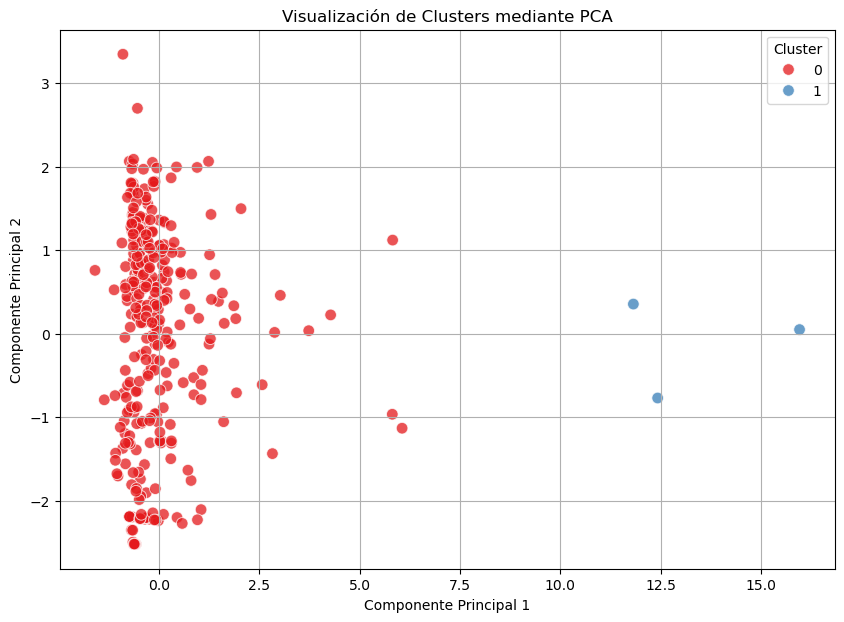


Productos pertenecientes al Cluster 1:


,ItemCode,Brand,ItemDescription,PCA1,PCA2
2,0000075000615,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,12.426353,-0.770633
3,0000075000622,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,15.961354,0.049440
4,0000075000639,CLORALEX,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,11.821207,0.354955


In [47]:
# 23. Visualizar los clusters en dos dimensiones mediante PCA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA


# ------------------------------------------------------------
# 1. Reducir las variables del clustering a 2 componentes
# ------------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=42
)

componentes_pca = pca.fit_transform(
    df_cluster_preparado
)


# ------------------------------------------------------------
# 2. Crear DataFrame para visualización
# ------------------------------------------------------------

df_pca = pd.DataFrame({
    'PCA1': componentes_pca[:, 0],
    'PCA2': componentes_pca[:, 1],
    'Cluster': clusters
})


# Incorporar información descriptiva
df_pca['ItemCode'] = df_resultados['ItemCode'].values
df_pca['Brand'] = df_resultados['Brand'].values
df_pca['ItemDescription'] = df_resultados['ItemDescription'].values


# ------------------------------------------------------------
# 3. Mostrar varianza explicada
# ------------------------------------------------------------

varianza_explicada = (
    pca.explained_variance_ratio_ * 100
)

print(
    f'Varianza explicada por PCA1: '
    f'{varianza_explicada[0]:.2f}%'
)

print(
    f'Varianza explicada por PCA2: '
    f'{varianza_explicada[1]:.2f}%'
)

print(
    f'Varianza explicada acumulada: '
    f'{varianza_explicada.sum():.2f}%'
)


# ------------------------------------------------------------
# 4. Gráfico de dispersión por cluster
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_pca,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    s=70,
    alpha=0.75
)

plt.title('Visualización de Clusters mediante PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.grid(True)
plt.legend(title='Cluster')

plt.show()


# ------------------------------------------------------------
# 5. Mostrar productos del cluster minoritario
# ------------------------------------------------------------

print('\nProductos pertenecientes al Cluster 1:')

display(
    df_pca.loc[
        df_pca['Cluster'] == 1,
        [
            'ItemCode',
            'Brand',
            'ItemDescription',
            'PCA1',
            'PCA2'
        ]
    ]
)

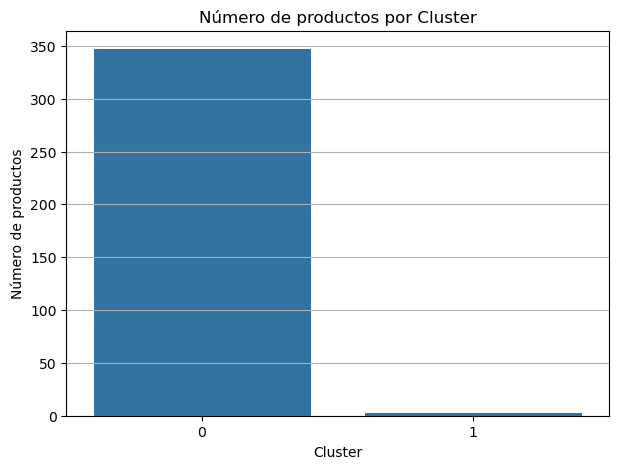

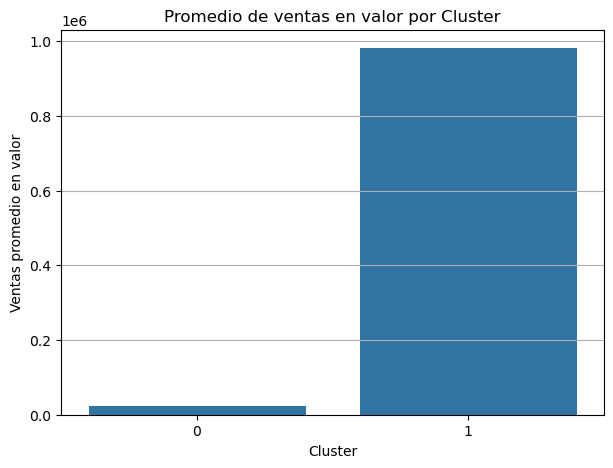

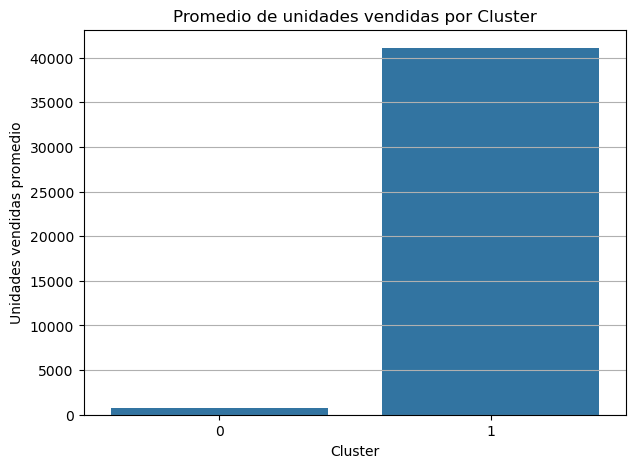

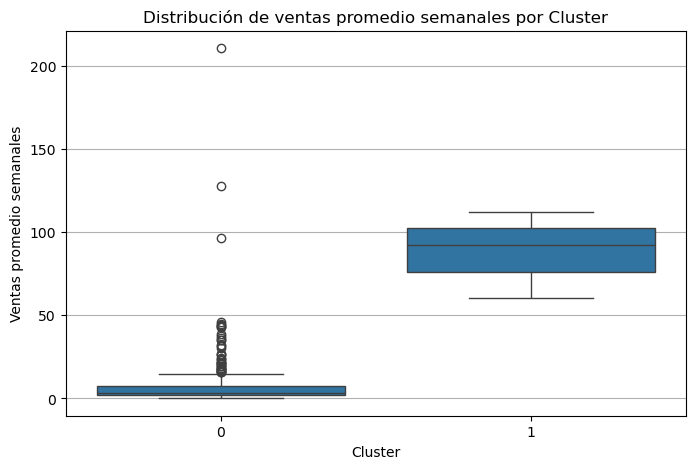

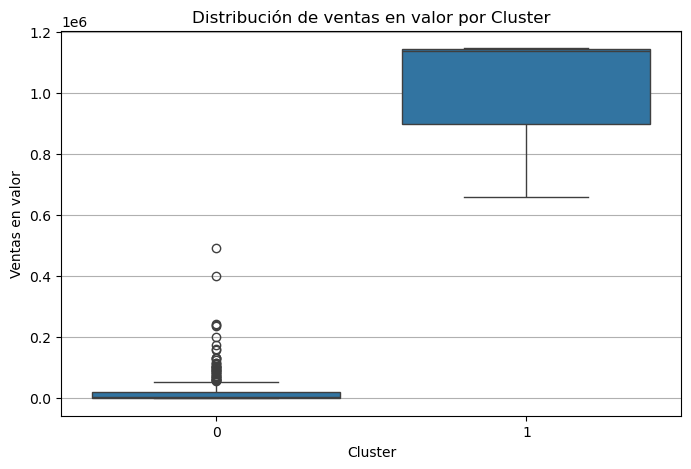

In [49]:
# 24. Generar visualizaciones adicionales para analizar los clusters

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 1. Número de productos por Cluster
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_resultados,
    x='Cluster'
)

plt.title('Número de productos por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de productos')
plt.grid(axis='y')

plt.show()


# ------------------------------------------------------------
# 2. Promedio de ventas en valor por Cluster
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_resultados,
    x='Cluster',
    y='TotalValueSales',
    estimator='mean',
    errorbar=None
)

plt.title('Promedio de ventas en valor por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Ventas promedio en valor')
plt.grid(axis='y')

plt.show()


# ------------------------------------------------------------
# 3. Promedio de unidades vendidas por Cluster
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_resultados,
    x='Cluster',
    y='TotalUnitSales',
    estimator='mean',
    errorbar=None
)

plt.title('Promedio de unidades vendidas por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Unidades vendidas promedio')
plt.grid(axis='y')

plt.show()


# ------------------------------------------------------------
# 4. Distribución de las ventas promedio semanales
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_resultados,
    x='Cluster',
    y='AvgWeeklySales'
)

plt.title('Distribución de ventas promedio semanales por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Ventas promedio semanales')
plt.grid(axis='y')

plt.show()


# ------------------------------------------------------------
# 5. Distribución de las ventas en valor
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_resultados,
    x='Cluster',
    y='TotalValueSales'
)

plt.title('Distribución de ventas en valor por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Ventas en valor')
plt.grid(axis='y')

plt.show()

In [51]:
# 25. Guardar los resultados del clustering y el modelo

import joblib

# Guardar productos con su Cluster asignado
df_resultados.to_csv(
    'productos_clusterizados.csv',
    index=False
)

# Guardar modelo y preprocesador
joblib.dump(kmeans_final, 'modelo_kmeans.pkl')
joblib.dump(preprocesador, 'preprocesador_clustering.pkl')

print("Resultados y modelo guardados correctamente.")

Resultados y modelo guardados correctamente.
